In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:


import matplotlib.pyplot as plt
import numpy as np
import sys


In [3]:
from taurex.log import disableLogging
import taurex
taurex.log.disableLogging()
from taurex.cache import OpacityCache,CIACache
OpacityCache().clear_cache()
OpacityCache().set_opacity_path("./xsec")
CIACache().set_cia_path("./cia")

In [ ]:
from taurex.mixin import enhance_class
from taurex.planet import Planet
from taurex.stellar import PhoenixStar, BlackbodyStar

pl = Planet(planet_mass=1, planet_radius=1, planet_distance= .1)
st = PhoenixStar(temperature=5770.0, radius=1.0, metallicity=1.0, phoenix_path='Phoenix/')


Numba not installed, using numpy instead


In [5]:
from taurex.data.profiles.pressure import SimplePressureProfile

In [6]:
p1 = SimplePressureProfile(nlayers=100, atm_min_pressure=1e-2, atm_max_pressure=1e6)
p1.compute_pressure_profile()
ps = [p1,p1,p1]

In [7]:
from taurex.temperature import Guillot2010, NPoint, Isothermal

Alb = 0.0
f = 6 # tidal locking
from taurex.constants import AU, RJUP
REARTH = 6371*1e3
Teq = st.temperature*np.sqrt(st.radius/(pl.semiMajorAxis*AU))*np.power( (1-Alb)/f, 0.25) 

tp1 = Guillot2010(T_irr=1.4*Teq, kappa_irr=0.01, kappa_v1=0.004, kappa_v2=0.004)
tp2 = Guillot2010(T_irr=1.18*Teq, kappa_irr=0.01, kappa_v1=0.004, kappa_v2=0.004)
tp3 = Guillot2010(T_irr=Teq*1, kappa_irr=0.01, kappa_v1=0.004, kappa_v2=0.004)

temperatures = [tp1,tp2,tp3]

In [8]:
f = 2 # tidal locking
REARTH = 6371*1e3
Teq = st.temperature*np.sqrt(st.radius/(pl.semiMajorAxis*AU))*np.power( (1-Alb)/f, 0.25) 

tp4 = Isothermal(T=Teq*1.18)
tp5 = Isothermal(T=Teq)
tp6 = Isothermal(T=10)

tps_rock = [tp4,tp5,tp6]

In [9]:
from taurex.data.profiles.chemistry import TaurexChemistry
from taurex.chemistry import ConstantGas
#from taurex_ggchem import GGChem

In [10]:
from taurex.chemistry import TaurexChemistry
ch1 = TaurexChemistry(fill_gases=['Na','O'],ratio=[2.,])
from taurex.chemistry import ConstantGas
sio = ConstantGas('SiO',mix_ratio=1e-2)
co2 = ConstantGas('CO2',mix_ratio=1e-12)
n2 = ConstantGas('N2',mix_ratio=1e-12)

ch1.addGas(sio)
ch1.addGas(co2)
ch1.addGas(n2)

chemistries = [ch1,ch1,ch1]

In [11]:
from taurex.contributions import AbsorptionContribution
from taurex.contributions import CIAContribution
from taurex.contributions import RayleighContribution
ctribs = [[AbsorptionContribution(), RayleighContribution(), CIAContribution(cia_pairs=['CO2-CO2', 'N2-N2'])],
                                [AbsorptionContribution(),RayleighContribution(), CIAContribution(cia_pairs=['CO2-CO2', 'N2-N2'])],
                                [AbsorptionContribution()],RayleighContribution(), CIAContribution(cia_pairs=['CO2-CO2', 'N2-N2']),]

In [ ]:
period = pl.orbitalPeriod

pl.transitTime
pl._mid_time = 0 #T_c, leave at 0
pl._eccentricity = 0.06 # planet value
pl._pericentre_long = 228 #w

pl.pericentre_time = 0.0
pl.ascending_node_long = 0.0

transittime = pl.transitTime*1.15741e-5
begin = pl._mid_time-period/2-2*transittime
end = pl._mid_time+period/2+2*transittime

phases = np.linspace(begin, end, 200)

In [28]:
print(pl.transitTime)

3000.0


In [13]:
#from taurex_phase.model import HotSpotPhaseCurveModel
from explor.model import HotSpotPhaseCurveModel
hs = HotSpotPhaseCurveModel(phases=phases,
                 temperature_profiles=temperatures,
                 chemistry=chemistries,
                 nlayers=[70]*3,
                 pressure_profile=ps,
                 planet=pl,
                 star=st,
                 observation=None,
                 contributions=ctribs,
                 alpha_hs=45.0,
                 delta_hs = -40.0,
                 ngauss=40,
                 use_directimage=False,
                 use_cuda=False,
                 use_orbitals = True,
                 temperature_constraints = 10, res_grid=[400, 0.2,18.5])

None
File already here...  teff05750_logg4.0_MH1.0.pickle
File already here...  teff05750_logg4.5_MH1.0.pickle
File already here...  teff06000_logg4.0_MH1.0.pickle
File already here...  teff06000_logg4.5_MH1.0.pickle


In [14]:
hs.build()


In [ ]:
#hs._phase_day.model()

In [ ]:
#hs._phase_day.chemistry.mixProfile

In [15]:
o = hs.model()

/Users/lorenzo/anaconda3/envs/python312_env/lib/python3.12/site-packages/explor/util/pylightcurve.py:84: RuntimeWarning: divide by zero encountered in scalar divide
  position_vector = planet_orbit(period, sma_over_rs / rp_over_rs, eccentricity, inclination, periastron + 180,
/Users/lorenzo/anaconda3/envs/python312_env/lib/python3.12/site-packages/explor/util/pylightcurve.py:88: RuntimeWarning: divide by zero encountered in scalar divide
  position_vector[0] < 0, 1.0 + 5.0 / rp_over_rs,
/Users/lorenzo/anaconda3/envs/python312_env/lib/python3.12/site-packages/explor/util/pylightcurve.py:91: RuntimeWarning: divide by zero encountered in scalar divide
  return (1.0 + fp_over_fs * transit_flux_drop([0, 0, 0, 0], 1 / rp_over_rs, projected_distance,
/Users/lorenzo/anaconda3/envs/python312_env/lib/python3.12/site-packages/explor/util/pylightcurve.py:115: RuntimeWarning: invalid value encountered in subtract
  dif_z_rprs = rp_over_rs - z_over_rs
/Users/lorenzo/anaconda3/envs/python312_env/lib/

In [19]:
np.array(o[1]).shape

(1811, 200)

In [16]:
import pandas as pd
import numpy as np
from taurex.binning import FluxBinner
from taurex.util.util import create_grid_res

ariel = pd.read_csv('./ARIEL/arielrad_TOI431/tier2.csv', skiprows=6)
fb_ariel = FluxBinner(ariel['Wavelength [um]'], ariel['Bandwidth [um]'])

In [17]:
wave = ariel['Wavelength [um]'].values
band = ariel['Bandwidth [um]'].values
#error_w_floor = ariel['Noise on Transit Floor [ppm]'].values*1e-6/np.sqrt(1)
error_w_hour = ariel['Total Noise [ppm]'].values*1e-6/np.sqrt(1)

In [18]:
flux = np.zeros((len(hs._orbitals), len(wave)))
fb2 = FluxBinner(wave)
for i, orb in enumerate(hs._orbitals):
    _, flux[i, :], _, _ = fb2.bindown(10000/hs.wls[0][::-1],np.array(o[1])[::-1,i])

In [20]:
dtsampled = np.mean(hs._orbitals[1:] - hs._orbitals[:-1])*24

In [21]:
dh = error_w_hour / np.sqrt(dtsampled)

5
45


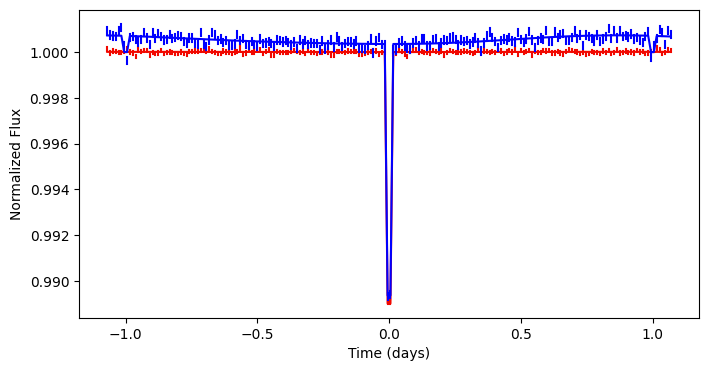

In [22]:
plt.figure(figsize=(8,4))
Nphases = int(len(np.array(o[1])[:,0])/2)
from matplotlib.pyplot import cm
c = cm.jet(np.linspace(1, 0, len(wave)))

wl = [1.4, 5]
for i, w in enumerate(wl):
    idx = (np.abs(wave - w)).argmin()
    print(idx)
    plt.plot(hs._orbitals, flux[:, idx], color=c[idx])
    rand = np.random.normal(flux[:, idx], dh[idx])
    plt.plot((hs._orbitals,hs._orbitals), (rand-dh[idx],rand+dh[idx]),'-', color=c[idx])
    #plt.plot((hs._orbitals,hs._orbitals), (flux[:, idx]-dh[idx],flux[:, idx]+dh[idx]),'-', color=c[idx])
plt.xlabel('Time (days)')
plt.ylabel('Normalized Flux')
#plt.ylim(0.96, 1.008)
#plt.savefig('phasecurve_tp_55cnce_sio1e-5_0_50_180.pdf', bbox_inches='tight')
plt.show()

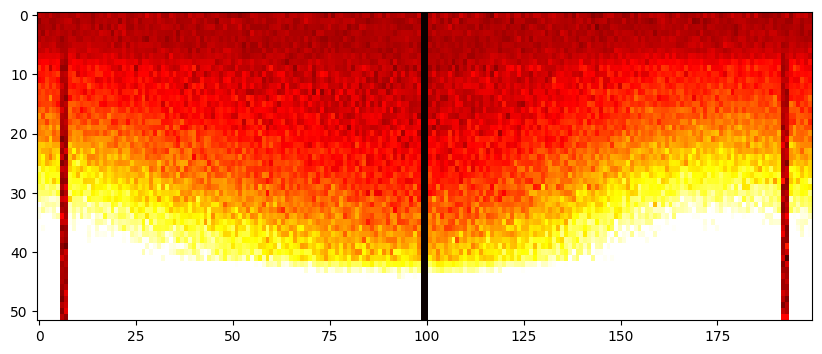

In [24]:
plt.figure(figsize=(10,4))
plt.imshow(np.random.normal(flux, dh/np.sqrt(100)).T, aspect='auto', vmin=0.9999, vmax=1.0003, cmap='hot')

plt.show()

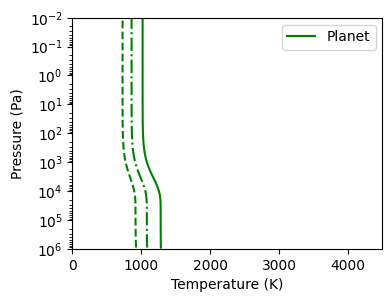

In [25]:
plt.figure(figsize=(4, 3))

plt.plot(hs.temperatureProfile[0,:], hs.pressureProfile[0,:], color='green', label='Planet')
plt.plot(hs.temperatureProfile[1,:], hs.pressureProfile[0,:],'-.', color='green')
plt.plot(hs.temperatureProfile[2,:], hs.pressureProfile[0,:],'--', color='green')

plt.legend()
plt.yscale('log')
plt.gca().invert_yaxis()
plt.xlim(000, 4500)
plt.ylim(1e6, 1e-2)
plt.xlabel('Temperature (K)')
plt.ylabel('Pressure (Pa)')
#plt.savefig('all_tp.png',bbox_inches='tight', dpi=180)
plt.show()

In [26]:
wl1min = 2.
wl1max = 7.8

wl2min = 5.8
wl2max = 7.

wl1 = (wl1min+wl1max)/2 
wb1 = (wl1max-wl1min) 

wl2 = (wl2min+wl2max)/2 
wb2 = (wl2max-wl2min) 

waves = np.array([wl1,wl2,])
wabin = np.array([wb1,wb2,])

photobin = FluxBinner(waves, wabin)
light_curves = []
light_curves_er = []
for i in range(flux.shape[0]):
    flubber = photobin.bindown(wave, flux[i,:], error=dh)
    light_curves.append(flubber[1])
    light_curves_er.append(flubber[2])
light_curves = np.array(light_curves)
light_curves_er = np.array(light_curves_er)

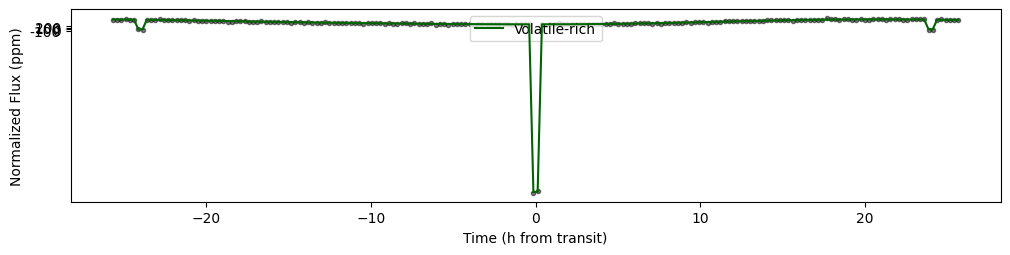

In [27]:
np.random.seed(2)

NPhase = 4

plt.figure(figsize=(12,2.5))
err0 = light_curves_er[:,0]/np.sqrt(NPhase)
err1 = light_curves_er[:,1]/np.sqrt(NPhase)
tval = (hs._orbitals-np.mean(hs._orbitals))*24

plt.plot(tval, light_curves[:,0],'-', color='darkgreen', zorder=10, label='Volatile-rich')
plt.errorbar(tval, np.random.normal(light_curves[:,0], err0), yerr=err0, fmt='.', alpha=0.5, color='black')

#plt.ylim(0.9999, 1.00025)
#plt.xlim(np.min(tval), np.max(tval))

plt.yticks([0.9999, 1, 1.0001, 1.0002], [-100, 0, 100, 200])

plt.legend(ncols=3, loc='upper center')

plt.xlabel('Time (h from transit)')
plt.ylabel('Normalized Flux (ppm)')
#plt.savefig('phasecurve.png', bbox_inches='tight', dpi=200)
plt.show()